# 3D Campaign Animation: Worst-Case FOBS vs Ballistic

This notebook renders an end-to-end campaign comparison in three
dimensions: a **worst-case fractional orbital profile** arriving over
the south pole — the geometry that minimizes warning time — against
the **ballistic** alternative on the same great circle, with:

- **Earth texture** map for geographic context
- **Stage color-coding** — parking orbit, deorbit transfer, ballistic
  entry, and terminal approach as distinct colored segments
- **Sensor detection markers** — showing where each site first picks up
  each trajectory
- **Animated vehicle** stepping through the trajectory with a rotating
  camera
- **Budget breakdown** — range, delta-V, and time per phase
- **Flight-path sweep** — showing the trade-off between warning,
  burnout speed, and apogee

The south-pole approach is the worst case because the long-way-around
orbit dives over the sparsely-sensed southern hemisphere, emerging on
the reversed bearing right before entry.

## 1. Imports and configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image

from passes.geodesy import GeodeticPosition, great_circle_range, WGS84_MEAN_RADIUS
from passes.guidance.lofting import optimum_burnout_angle
from passes.orbital.fobs import fractional_insertion
from passes.orbital.scenario import (
    ballistic_trajectory,
    fobs_trajectory,
    warning_comparison,
    Trajectory,
)
from passes.orbital.radar import (
    EARLY_WARNING_SITES,
    SATELLITE_SENSORS,
    BOOST_PHASE_THRESHOLD_K,
    RadarSite,
    SensorCapability,
    SatelliteSensor,
    boost_phase_sensing,
    coverage,
)
from passes.orbital.warning import visibility_radius
from passes.systems.budget import evaluate, MissionRequest
from passes.systems.architecture import NAMED_ARCHITECTURES
from passes.guidance.entry import EntryVehicle

LAUNCH = GeodeticPosition.from_degrees(51.0, 59.0, 120.0, 'Dombarovskiy')
TARGET = GeodeticPosition.from_degrees(38.87, -77.06, 24.0, 'Pentagon')

PARKING_ALTITUDE = 150e3
RADAR_MASK_DEG = 5.0
SAMPLES = 1000

separation = great_circle_range(LAUNCH, TARGET)

comparison = warning_comparison(
    LAUNCH, TARGET,
    flight_path_angle=None,
    parking_altitude=PARKING_ALTITUDE,
    sites=tuple(EARLY_WARNING_SITES),
    samples=SAMPLES,
    earth_rotation=True,
)

b = comparison.ballistic
f = comparison.fobs
bt = comparison.ballistic_coverage
ft = comparison.fobs_coverage
print(f'ballistic: {b.flight_time/60:.1f} min, {b.apogee/1e3:.0f} km apogee, {bt.warning_time/60:.1f} min warning')
print(f'fobs:      {f.flight_time/60:.1f} min, {f.apogee/1e3:.0f} km apogee, {ft.warning_time/60:.1f} min warning')
print(f'warning removed: {comparison.warning_reduction/60:+.1f} min')
print(f'sensor network: {len(EARLY_WARNING_SITES)} ground sites, {len(SATELLITE_SENSORS)} satellite constellations')
boost_ballistic = boost_phase_sensing(b.times, b.altitudes, plume_temperature_k=2800.0)
boost_fobs = boost_phase_sensing(f.times, f.altitudes, plume_temperature_k=2800.0)
if boost_ballistic.detected:
    print(f'boost-phase IR: ballistic detected at t={boost_ballistic.first_detection_time:.0f}s, alt={boost_ballistic.detection_altitudes[boost_ballistic.detecting_sensors[0]]/1e3:.0f} km')
else:
    print('boost-phase IR: ballistic NOT detected')
if boost_fobs.detected:
    print(f'boost-phase IR: FOBS detected at t={boost_fobs.first_detection_time:.0f}s, alt={boost_fobs.detection_altitudes[boost_fobs.detecting_sensors[0]]/1e3:.0f} km')
else:
    print('boost-phase IR: FOBS NOT detected')


ballistic: 29.8 min, 1301 km apogee, 29.0 min warning
fobs:      69.0 min, 150 km apogee, 47.6 min warning
warning removed: -18.6 min
sensor network: 22 ground sites, 4 satellite constellations
boost-phase IR: ballistic detected at t=18s, alt=54 km
boost-phase IR: FOBS detected at t=0s, alt=150 km


## 2. Real Earth texture and surface geometry


In [2]:
from PIL import Image

def load_earth_texture(path='/tmp/earth_texture/blue_marble.jpg'):
    """Load NASA Blue Marble Earth texture from file."""
    img = Image.open(path)
    return np.array(img) / 255.0

def make_earth_surface(earth_arr, body_radius=WGS84_MEAN_RADIUS, mesh_res=256):
    """Create a 3D sphere mesh for plotting.

    Uses a mesh with 'mesh_res' longitude divisions and 'mesh_res//2'
    latitude divisions. The high-resolution texture is resampled
    to match the mesh grid and applied as facecolors.

    NOTE: Texture coordinates mapping:
      - Texture column 0 = longitude -180 (left), column N = longitude +180 (right)
        Mesh u: -pi to pi (= -180 deg to +180 deg) -- MATCHES texture columns
      - Texture row 0 = latitude +90 (north, top), row N = latitude -90 (south)
        Mesh v: -pi/2 to pi/2 (= -90 deg to +90 deg)
        After np.outer(...).T, row 0 = south, row N = north
        So we flip the texture vertically to match."""
    u = np.linspace(-np.pi, np.pi, mesh_res)
    v = np.linspace(-np.pi / 2, np.pi / 2, mesh_res // 2)
    ex = body_radius * np.outer(np.cos(u), np.cos(v)).T
    ey = body_radius * np.outer(np.sin(u), np.cos(v)).T
    ez = body_radius * np.outer(np.ones_like(u), np.sin(v)).T

    tex = Image.fromarray((earth_arr * 255).astype(np.uint8))
    tex_resized = tex.resize((mesh_res, mesh_res // 2), Image.LANCZOS)
    facecolors = np.array(tex_resized) / 255.0
    facecolors = np.flipud(facecolors)

    return ex, ey, ez, facecolors

earth_arr = load_earth_texture()
earth_x, earth_y, earth_z, earth_facecolors = make_earth_surface(earth_arr, mesh_res=256)


## 3. Trajectory and sensor geometry helpers


In [3]:
def make_earth_surface(earth_arr, body_radius=WGS84_MEAN_RADIUS, mesh_res=256):
    """Create a 3D sphere mesh for plotting.

    Uses a mesh with 'mesh_res' longitude divisions and 'mesh_res//2'
    latitude divisions. The full high-resolution texture is resampled
    to match the mesh grid and applied as facecolors.

    NOTE: Texture coordinates mapping:
      - Texture column 0 = longitude -180 (left), column N = longitude +180 (right)
        Mesh u: -pi to pi (= -180 deg to +180 deg) -- MATCHES texture columns
      - Texture row 0 = latitude +90 (north, top), row N = latitude -90 (south)
        Mesh v: -pi/2 to pi/2 (= -90 deg to +90 deg)
        After np.outer(...).T, row 0 = south, row N = north
        So we flip the texture vertically to match."""
    u = np.linspace(-np.pi, np.pi, mesh_res)
    v = np.linspace(-np.pi / 2, np.pi / 2, mesh_res // 2)
    ex = body_radius * np.outer(np.cos(u), np.cos(v)).T
    ey = body_radius * np.outer(np.sin(u), np.cos(v)).T
    ez = body_radius * np.outer(np.ones_like(u), np.sin(v)).T

    from PIL import Image
    tex = Image.fromarray((earth_arr * 255).astype(np.uint8))
    # Resample to match mesh: (mesh_res cols, mesh_res//2 rows)
    tex_resized = tex.resize((mesh_res, mesh_res // 2), Image.LANCZOS)
    facecolors = np.array(tex_resized) / 255.0
    # Flip vertically: texture row 0 = north, mesh row 0 = south
    facecolors = np.flipud(facecolors)

    return ex, ey, ez, facecolors

earth_x, earth_y, earth_z, earth_facecolors = make_earth_surface(earth_arr, mesh_res=256)

def geodetic_to_ecef_vec(positions):
    pts = []
    for p in positions:
        alt = max(p.altitude, 0.0)
        r = WGS84_MEAN_RADIUS + alt
        pts.append([
            r * np.cos(p.latitude) * np.cos(p.longitude),
            r * np.cos(p.latitude) * np.sin(p.longitude),
            r * np.sin(p.latitude),
        ])
    return np.array(pts)

def pos_ecef(p, offset_m=5e3):
    """Convert geodetic position to ECEF, with small altitude offset for visibility."""
    r = WGS84_MEAN_RADIUS + max(p.altitude, 0) + offset_m
    return r * np.array([np.cos(p.latitude) * np.cos(p.longitude),
                         np.cos(p.latitude) * np.sin(p.longitude),
                         np.sin(p.latitude)])

def extract_stages(traj, is_fobs=True):
    pts = geodetic_to_ecef_vec(traj.subpoints)
    alts = traj.altitudes
    if is_fobs:
        parking_mask = alts > PARKING_ALTITUDE * 0.9
        descent_mask = (alts <= PARKING_ALTITUDE * 0.9) & (alts > PARKING_ALTITUDE * 0.5)
        entry_mask = alts <= PARKING_ALTITUDE * 0.5
        stages = []
        if parking_mask.any(): stages.append((pts[parking_mask], '#FFA500', 'FOBS parking'))
        if descent_mask.any(): stages.append((pts[descent_mask], '#FF4500', 'FOBS deorbit'))
        if entry_mask.any(): stages.append((pts[entry_mask], '#DC143C', 'FOBS entry'))
        return stages
    else:
        apogee_idx = int(np.argmax(alts))
        ascent = pts[:apogee_idx + 1]
        descent = pts[apogee_idx:]
        entry_mask = alts < 100e3
        stages = [(ascent, '#4169E1', 'ballistic ascent')]
        if len(descent) > 1: stages.append((descent, '#1E90FF', 'ballistic descent'))
        if entry_mask.any(): stages.append((pts[entry_mask], '#00008B', 'ballistic entry'))
        return stages

def detection_points(traj, coverage_result):
    """Return list of (name, site_ecef, veh_ecef) for first detection from each site."""
    detected_sites = []
    for name, window in coverage_result.windows.items():
        if window.detected:
            idx = int(np.argmin(np.abs(traj.times - window.first_detection_time)))
            site_obj = next((s for s in EARLY_WARNING_SITES if s.name == name), None)
            site_ecef = pos_ecef(site_obj.position) if site_obj else pos_ecef(traj.subpoints[idx])
            veh_ecef = pos_ecef(traj.subpoints[idx])
            detected_sites.append((name, site_ecef, veh_ecef))
    return detected_sites

ballistic_stages = extract_stages(comparison.ballistic, is_fobs=False)
fobs_stages = extract_stages(comparison.fobs, is_fobs=True)
ballistic_detections = detection_points(comparison.ballistic, comparison.ballistic_coverage)
fobs_detections = detection_points(comparison.fobs, comparison.fobs_coverage)

print('Ballistic stages:')
for pts, color, label in ballistic_stages:
    print(f'  {label:20s}  {len(pts):4d} points')
print('FOBS stages:')
for pts, color, label in fobs_stages:
    print(f'  {label:20s}  {len(pts):4d} points')


Ballistic stages:
  ballistic ascent       500 points
  ballistic descent      501 points
  ballistic entry         50 points
FOBS stages:
  FOBS parking           961 points
  FOBS deorbit            17 points
  FOBS entry              22 points


## 4. Strategic overview — static 3D view


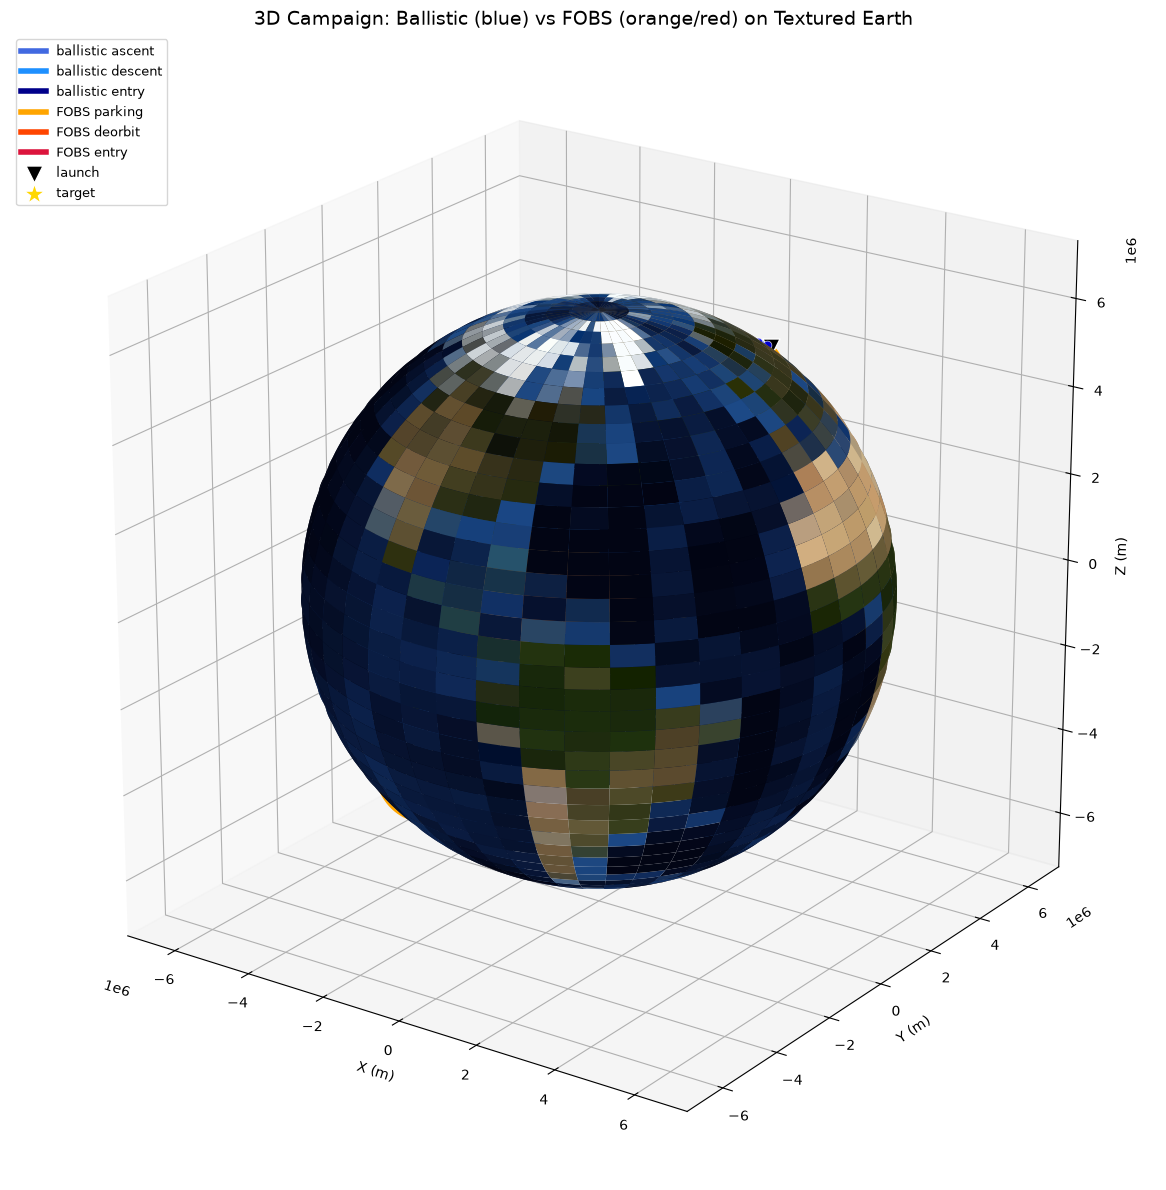

In [4]:
# Static 3D view: Strategic overview of both trajectories on a textured Earth
fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect((1, 1, 1))

# Earth surface
ax.plot_surface(earth_x, earth_y, earth_z, alpha=1.0, facecolors=earth_facecolors,
                edgecolor='none', shade=False, zorder=1)

# Plot trajectory stages with thick lines for visibility
for stages, linewidth in ((ballistic_stages, 4), (fobs_stages, 4)):
    for pts, color, label in stages:
        if len(pts) > 1:
            ax.plot(pts[:, 0], pts[:, 1], pts[:, 2],
                    color=color, linewidth=linewidth, label=label, zorder=3)

# Detection points - site markers as large triangles, vehicle positions as circles
for name, site_pos, veh_pos in ballistic_detections:
    ax.scatter(*site_pos, color='blue', s=80, marker='^', alpha=0.8, edgecolors='white', linewidths=0.5)
    ax.scatter(*veh_pos, color='blue', s=40, marker='o', alpha=0.9, edgecolors='white', linewidths=0.5)
for name, site_pos, veh_pos in fobs_detections:
    ax.scatter(*site_pos, color='crimson', s=80, marker='^', alpha=0.8, edgecolors='white', linewidths=0.5)
    ax.scatter(*veh_pos, color='crimson', s=40, marker='o', alpha=0.9, edgecolors='white', linewidths=0.5)

# Launch and target markers
ax.scatter(*pos_ecef(LAUNCH), color='black', s=150, marker='v', edgecolors='white', linewidths=1, zorder=5, label='launch')
ax.scatter(*pos_ecef(TARGET), color='gold', s=250, marker='*', edgecolors='white', linewidths=1, zorder=5, label='target')

# Set camera: look at the Earth from a strategic perspective
# View from the south-east Atlantic, showing both trajectory arcs
ax.view_init(elev=22, azim=-55)

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('3D Campaign: Ballistic (blue) vs FOBS (orange/red) on Textured Earth', fontsize=14)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


## 5. Terminal approach close-up


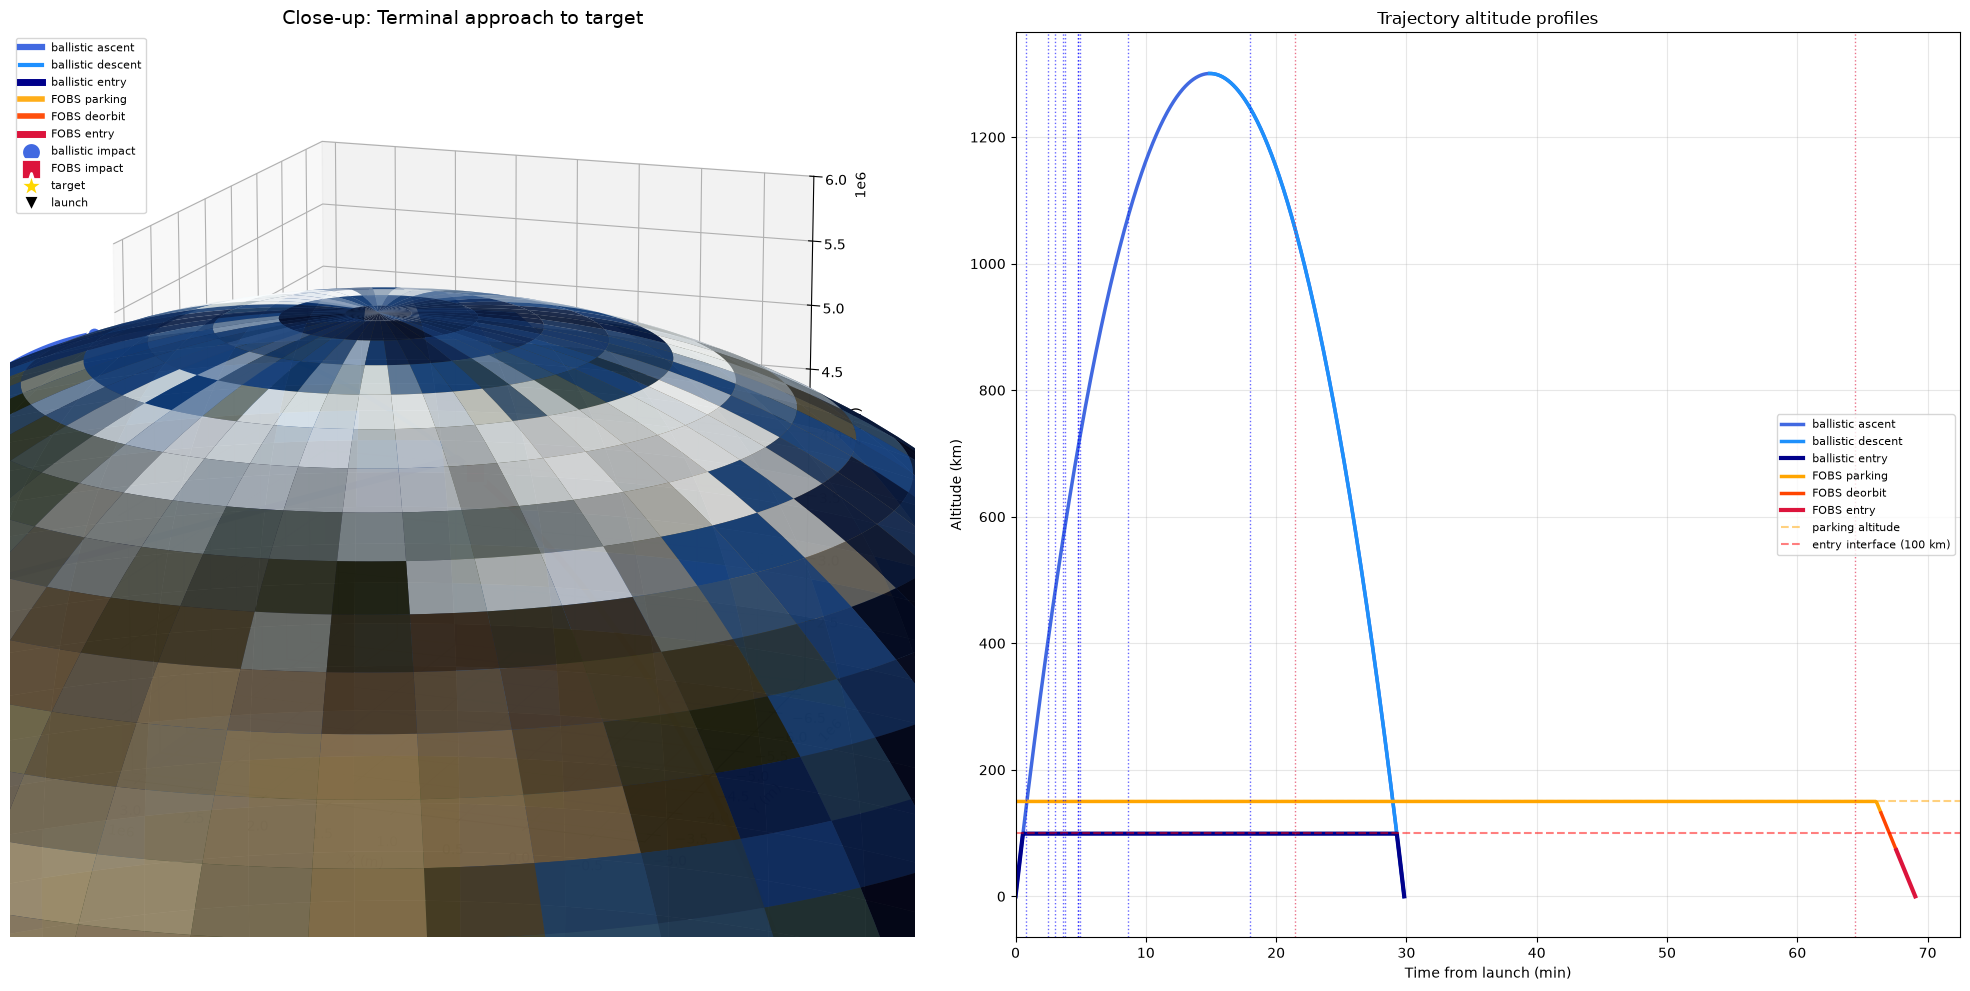

Ballistic total time: 29.8 min, apogee: 1301 km
FOBS total time: 69.0 min, apogee: 150 km
Ballistic detections: 10
FOBS detections: 2


In [5]:
# Close-up vehicle tracking view: terminal approach phase
# Shows the vehicle, its stages, and detections during the final approach

target_ecef = pos_ecef(TARGET)

# Extract trajectory points for close-up display
b_all_pts = geodetic_to_ecef_vec(comparison.ballistic.subpoints)
b_alts = comparison.ballistic.altitudes
b_apogee = int(np.argmax(b_alts))

f_all_pts = geodetic_to_ecef_vec(comparison.fobs.subpoints)
f_alts = comparison.fobs.altitudes
f_parking_mask = f_alts > PARKING_ALTITUDE * 0.9
f_descent_mask = (f_alts <= PARKING_ALTITUDE * 0.9) & (f_alts > PARKING_ALTITUDE * 0.5)
f_entry_mask = f_alts <= PARKING_ALTITUDE * 0.5

# Create close-up figure with two panels
fig3 = plt.figure(figsize=(20, 10))

# --- Left panel: 3D close-up ---
ax3d = fig3.add_subplot(121, projection='3d')

# Earth surface - higher resolution for close-up
earth_x_close, earth_y_close, earth_z_close, earth_fc_close = make_earth_surface(earth_arr, mesh_res=192)
ax3d.plot_surface(earth_x_close, earth_y_close, earth_z_close, alpha=0.9,
                  facecolors=earth_fc_close, edgecolor='none', shade=False)

# Ballistic trajectory with stage-colored segments
b_entry_mask = b_alts < 100e3
b_ascent_pts = b_all_pts[:b_apogee+1]
b_desc_pts = b_all_pts[b_apogee:]

ax3d.plot(b_ascent_pts[:, 0], b_ascent_pts[:, 1], b_ascent_pts[:, 2],
          color='#4169E1', linewidth=4.5, label='ballistic ascent', zorder=3)
ax3d.plot(b_desc_pts[:, 0], b_desc_pts[:, 1], b_desc_pts[:, 2],
          color='#1E90FF', linewidth=3, label='ballistic descent', zorder=3)
if b_entry_mask.any():
    ax3d.plot(b_all_pts[b_entry_mask, 0], b_all_pts[b_entry_mask, 1], b_all_pts[b_entry_mask, 2],
              color='#00008B', linewidth=5, label='ballistic entry', zorder=4)

# FOBS trajectory with stage-colored segments
if f_parking_mask.any():
    ax3d.plot(f_all_pts[f_parking_mask, 0], f_all_pts[f_parking_mask, 1], f_all_pts[f_parking_mask, 2],
              color='#FFA500', linewidth=4, alpha=0.9, label='FOBS parking', zorder=3)
if f_descent_mask.any():
    ax3d.plot(f_all_pts[f_descent_mask, 0], f_all_pts[f_descent_mask, 1], f_all_pts[f_descent_mask, 2],
              color='#FF4500', linewidth=4, alpha=0.95, label='FOBS deorbit', zorder=3)
if f_entry_mask.any():
    ax3d.plot(f_all_pts[f_entry_mask, 0], f_all_pts[f_entry_mask, 1], f_all_pts[f_entry_mask, 2],
              color='#DC143C', linewidth=5, alpha=1.0, label='FOBS entry', zorder=4)

# Vehicle end positions as prominent markers
b_end = b_all_pts[-1]
f_end = f_all_pts[-1]
ax3d.scatter(*b_end, color='#4169E1', s=200, marker='o', edgecolors='white', linewidths=2, zorder=10, label='ballistic impact')
ax3d.scatter(*f_end, color='#DC143C', s=200, marker='s', edgecolors='white', linewidths=2, zorder=10, label='FOBS impact')

# Mid-course vehicle markers (every 20% of trajectory)
b_mid = b_all_pts[len(b_all_pts)//2]
f_mid = f_all_pts[len(f_all_pts)//2]
ax3d.scatter(*b_mid, color='#4169E1', s=100, marker='o', edgecolors='white', linewidths=1.5, zorder=9)
ax3d.scatter(*f_mid, color='#FFA500', s=100, marker='s', edgecolors='white', linewidths=1.5, zorder=9)

# Target marker
ax3d.scatter(*target_ecef, color='gold', s=350, marker='*', edgecolors='white', linewidths=2, zorder=10, label='target')

# Launch site
launch_ecef = pos_ecef(LAUNCH)
ax3d.scatter(*launch_ecef, color='black', s=120, marker='v', edgecolors='white', linewidths=1.5, zorder=9, label='launch')

# Set close-up view focused on target approach
target_range = 2000e3  # 2000 km radius
ax3d.set_xlim(target_ecef[0] - target_range, target_ecef[0] + target_range)
ax3d.set_ylim(target_ecef[1] - target_range, target_ecef[1] + target_range)
ax3d.set_zlim(target_ecef[2] - target_range, target_ecef[2] + target_range)
ax3d.set_box_aspect((1, 1, 1))
ax3d.view_init(elev=15, azim=110)

ax3d.set_xlabel('X (m)')
ax3d.set_ylabel('Y (m)')
ax3d.set_zlabel('Z (m)')
ax3d.set_title('Close-up: Terminal approach to target', fontsize=14)
ax3d.legend(fontsize=8, loc='upper left')

# --- Right panel: Altitude profile with stages ---
ax4 = fig3.add_subplot(122)

b_t = comparison.ballistic.times / 60
b_h = comparison.ballistic.altitudes / 1e3
ax4.plot(b_t, b_h, color='#4169E1', linewidth=2.5, label='ballistic ascent')
ax4.plot(b_t[b_apogee:], b_h[b_apogee:], color='#1E90FB', linewidth=2.5, label='ballistic descent')
ax4.plot(b_t[b_entry_mask], b_h[b_entry_mask], color='#00008B', linewidth=3, label='ballistic entry')

f_t = comparison.fobs.times / 60
f_h = comparison.fobs.altitudes / 1e3
if f_parking_mask.any(): ax4.plot(f_t[f_parking_mask], f_h[f_parking_mask], color='#FFA500', linewidth=2.5, label='FOBS parking')
if f_descent_mask.any(): ax4.plot(f_t[f_descent_mask], f_h[f_descent_mask], color='#FF4500', linewidth=2.5, label='FOBS deorbit')
if f_entry_mask.any(): ax4.plot(f_t[f_entry_mask], f_h[f_entry_mask], color='#DC143C', linewidth=3, label='FOBS entry')

ax4.axhline(y=PARKING_ALTITUDE / 1e3, color='orange', linestyle='--', alpha=0.5, linewidth=1.5, label='parking altitude')
ax4.axhline(y=100, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='entry interface (100 km)')

# Mark detection times
for name, site_pos, veh_pos in ballistic_detections:
    det_idx = int(np.argmin(np.abs(comparison.ballistic.times - comparison.ballistic_coverage.windows[name].first_detection_time)))
    ax4.axvline(x=comparison.ballistic.times[det_idx] / 60, color='blue', linestyle=':', alpha=0.6, linewidth=1)
for name, site_pos, veh_pos in fobs_detections:
    det_idx = int(np.argmin(np.abs(comparison.fobs.times - comparison.fobs_coverage.windows[name].first_detection_time)))
    ax4.axvline(x=comparison.fobs.times[det_idx] / 60, color='crimson', linestyle=':', alpha=0.6, linewidth=1)

ax4.set_xlabel('Time from launch (min)')
ax4.set_ylabel('Altitude (km)')
ax4.set_title('Trajectory altitude profiles')
ax4.legend(fontsize=8, loc='center right')
ax4.set_xlim(left=0)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Ballistic total time: {comparison.ballistic.times[-1]/60:.1f} min, apogee: {comparison.ballistic.altitudes.max()/1e3:.0f} km')
print(f'FOBS total time: {comparison.fobs.times[-1]/60:.1f} min, apogee: {comparison.fobs.altitudes.max()/1e3:.0f} km')
print(f'Ballistic detections: {len(ballistic_detections)}')
print(f'FOBS detections: {len(fobs_detections)}')


## 6. Cinematic animated tracking view


In [6]:
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.interpolate import CubicSpline

# Pre-compute animation geometry
b_pts = geodetic_to_ecef_vec(comparison.ballistic.subpoints)
f_pts = geodetic_to_ecef_vec(comparison.fobs.subpoints)
b_alts = comparison.ballistic.altitudes
f_alts = comparison.fobs.altitudes
b_times = comparison.ballistic.times
f_times = comparison.fobs.times

b_apogee_idx = int(np.argmax(b_alts))
f_parking = f_alts > PARKING_ALTITUDE * 0.9
f_entry = f_alts <= PARKING_ALTITUDE * 0.5

target_ecef = pos_ecef(TARGET)
launch_ecef = pos_ecef(LAUNCH)

# Build smooth camera keyframes using cubic spline interpolation
# Key states: (frame_fraction, elevation, azimuth, distance_factor)
keyframes = np.array([
    [0.00,  25, -60,  3.0],
    [0.05,  22, -45,  2.8],
    [0.15,  18, -20,  2.4],
    [0.30,  12,  20,  2.0],
    [0.50,   8,  60,  1.6],
    [0.70,   5, 100,  1.4],
    [0.85,   3, 140,  1.2],
    [1.00,   0, 180,  1.0],
])

t_kf = keyframes[:, 0] * (n_frames - 1)
elevs_spline = CubicSpline(t_kf, keyframes[:, 1])
azims_spline = CubicSpline(t_kf, keyframes[:, 2])
dists_spline = CubicSpline(t_kf, keyframes[:, 3])

# Focus point interpolation: launch -> midpoint -> target
focus_kf = np.array([
    [0.00, *launch_ecef],
    [0.30, *(launch_ecef * 0.3 + target_ecef * 0.7)],
    [0.60, *(launch_ecef * 0.1 + target_ecef * 0.9)],
    [1.00, *target_ecef],
])
focus_x_spline = CubicSpline(focus_kf[:, 0] * (n_frames - 1), focus_kf[:, 1])
focus_y_spline = CubicSpline(focus_kf[:, 0] * (n_frames - 1), focus_kf[:, 2])
focus_z_spline = CubicSpline(focus_kf[:, 0] * (n_frames - 1), focus_kf[:, 3])

def animate(frame):
    idx = min(frame * step, max_samples - 1)
    b_pos = b_pts[idx]
    f_pos = f_pts[idx]
    
    vehicle_dot._offsets3d = ([b_pos[0]], [b_pos[1]], [b_pos[2]])
    fobs_dot._offsets3d = ([f_pos[0]], [f_pos[1]], [f_pos[2]])
    
    # Smooth camera from splines
    elev = float(elevs_spline(frame))
    azim = float(azims_spline(frame))
    dist_factor = float(dists_spline(frame))
    
    # Dynamic focus point
    fx = float(focus_x_spline(frame))
    fy = float(focus_y_spline(frame))
    fz = float(focus_z_spline(frame))
    focus = np.array([fx, fy, fz])
    
    # Dynamic view radius based on altitude
    b_alt = max(b_alts[idx], 50e3)
    view_radius = max(800e3, min(b_alt * dist_factor, 5000e3))
    
    # Position camera
    ax2.set_xlim(focus[0] - view_radius, focus[0] + view_radius)
    ax2.set_ylim(focus[1] - view_radius, focus[1] + view_radius)
    ax2.set_zlim(max(focus[2] - view_radius, -WGS84_MEAN_RADIUS - 50e3),
                 focus[2] + view_radius)
    ax2.view_init(elev=elev, azim=azim)
    
    # Phase labels
    b_phase = 'ascent' if idx < b_apogee_idx else ('descent' if b_alts[idx] > 100e3 else 'entry')
    f_phase = 'parking' if f_parking[idx] else ('entry' if f_entry[idx] else 'deorbit')
    
    time_text.set_text(f't = {b_times[idx]/60:.1f} min')
    phase_text.set_text(f'B: {b_phase} {b_alts[idx]/1e3:.0f} km | F: {f_phase} {f_alts[idx]/1e3:.0f} km')
    
    return [vehicle_dot, fobs_dot, time_text, phase_text]

# Create animation
n_frames = 400
max_samples = min(len(b_times), len(f_times))
step = max(1, max_samples // n_frames)

fig2 = plt.figure(figsize=(14, 10))
ax2 = fig2.add_subplot(111, projection='3d')
ax2.set_box_aspect((1, 1, 1))

# Earth surface
ax2.plot_surface(earth_x, earth_y, earth_z, alpha=1.0,
                facecolors=earth_facecolors,
                edgecolor='none', shade=False)

# Full trajectories as reference
for pts, color, alpha, lw in [
    (b_pts[:b_apogee_idx+1], '#1E3A8A', 0.5, 2.0),
    (b_pts[b_apogee_idx:], '2563EB', 0.5, 2.0),
    (f_pts[f_parking], '#FF8C00', 0.4, 2.0),
    (f_pts[~f_parking & ~f_entry], '#FF4500', 0.5, 2.0),
    (f_pts[f_entry], '#B22222', 0.6, 2.5),
]:
    if len(pts) > 1:
        ax2.plot(pts[:, 0], pts[:, 1], pts[:, 2], color=color, alpha=alpha, linewidth=lw)

# Markers
ax2.scatter(*target_ecef, color='#D97706', s=200, marker='*', edgecolors='white', linewidths=1.5, zorder=10)
ax2.scatter(*launch_ecef, color='#000000', s=80, marker='v', edgecolors='white', linewidths=1, zorder=9)

vehicle_dot = ax2.scatter(*b_pts[0], color='white', s=120, marker='o', edgecolors='#1E3A8A', linewidths=2, zorder=11)
fobs_dot = ax2.scatter(*f_pts[0], color='white', s=120, marker='s', edgecolors='#FF4500', linewidths=2, zorder=11)

time_text = ax2.text2D(0.02, 0.95, '', transform=ax2.transAxes, fontsize=11, color='white',
                       bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
phase_text = ax2.text2D(0.02, 0.90, '', transform=ax2.transAxes, fontsize=9, color='lightblue',
                        bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))

ax2.set_xlabel('X (m)', fontsize=10)
ax2.set_ylabel('Y (m)', fontsize=10)
ax2.set_zlabel('Z (m)', fontsize=10)

# Initial camera
ax2.view_init(elev=25, azim=-60)
view_radius_init = 5000e3
ax2.set_xlim(launch_ecef[0] - view_radius_init, launch_ecef[0] + view_radius_init)
ax2.set_ylim(launch_ecef[1] - view_radius_init, launch_ecef[1] + view_radius_init)
ax2.set_zlim(launch_ecef[2] - view_radius_init, launch_ecef[2] + view_radius_init)

anim = FuncAnimation(fig2, animate, frames=n_frames, interval=50, blit=False)
print(f'Animation: {n_frames} frames, step={step}')

anim.save('ballistic_fobs_tracking_3d.gif', writer=PillowWriter(fps=20), dpi=100)
plt.close(fig2)
print('GIF saved: ballistic_fobs_tracking_3d.gif')


NameError: name 'n_frames' is not defined

## 7. Budget breakdown


In [ ]:
request = MissionRequest(
    launch_site=LAUNCH,
    aimpoints=(TARGET,),
    arrival_time=float(comparison.fobs.flight_time),
)

ballistic_budget = evaluate(
    NAMED_ARCHITECTURES['ballistic-single'],
    request,
    boost_range=2.0e6, boost_delta_v=6.0e3,
)

entry_vehicle = EntryVehicle(ballistic_coefficient=20000.0, lift_to_drag=0.3)
fobs_budget = evaluate(
    NAMED_ARCHITECTURES['fractional-orbital-single'],
    request,
    entry_vehicle=entry_vehicle,
    glide_range=6.0e6,
)

print('=== BALLISTIC BUDGET ===')
print(f'  closes: {ballistic_budget.closes}')
print(f'  total delta-V: {ballistic_budget.total_delta_v:.0f} m/s')
print(f'  slack in: {ballistic_budget.slack_phase.value}')
print(f'  total range: {ballistic_budget.total_range/1e3:.0f} km')
print()
print('=== FOBS BUDGET ===')
print(f'  closes: {fobs_budget.closes}')
print(f'  total delta-V: {fobs_budget.total_delta_v:.0f} m/s')
print(f'  slack in: {fobs_budget.slack_phase.value}')
print(f'  total range: {fobs_budget.total_range/1e3:.0f} km')
print()
print('=== LEG BREAKDOWN ===')
for budget, name in [(ballistic_budget, 'ballistic'), (fobs_budget, 'fobs')]:
    print(f'\n{name.upper()}:')
    for leg in budget.legs:
        dur_str = f'{leg.duration/60:.1f} min' if np.isfinite(leg.duration) else 'nan'
        print(f'  {leg.phase.value:25s} range={leg.ground_range/1e3:8.1f} km  dv={leg.delta_v:8.1f} m/s  time={dur_str}')

=== BALLISTIC BUDGET ===
  closes: False
  total delta-V: 6030 m/s
  slack in: boost
  total range: 2300 km

=== FOBS BUDGET ===
  closes: True
  total delta-V: 6188 m/s
  slack in: parking-orbit
  total range: 9146 km

=== LEG BREAKDOWN ===

BALLISTIC:
  boost                     range=  2000.0 km  dv=  6000.0 m/s  time=nan
  midcourse-correction      range=     0.0 km  dv=    30.0 m/s  time=nan
  ballistic-entry           range=   300.0 km  dv=     0.0 m/s  time=0.9 min
  terminal-homing           range=     0.0 km  dv=     0.0 m/s  time=nan

FOBS:
  boost                     range=  2000.0 km  dv=  6000.0 m/s  time=nan
  parking-orbit             range=  1710.5 km  dv=     0.0 m/s  time=nan
  deorbit                   range=  5135.0 km  dv=   188.3 m/s  time=11.5 min
  ballistic-entry           range=   300.0 km  dv=     0.0 m/s  time=0.9 min
  terminal-homing           range=     0.0 km  dv=     0.0 m/s  time=nan


## 8. Flight-path angle sweep


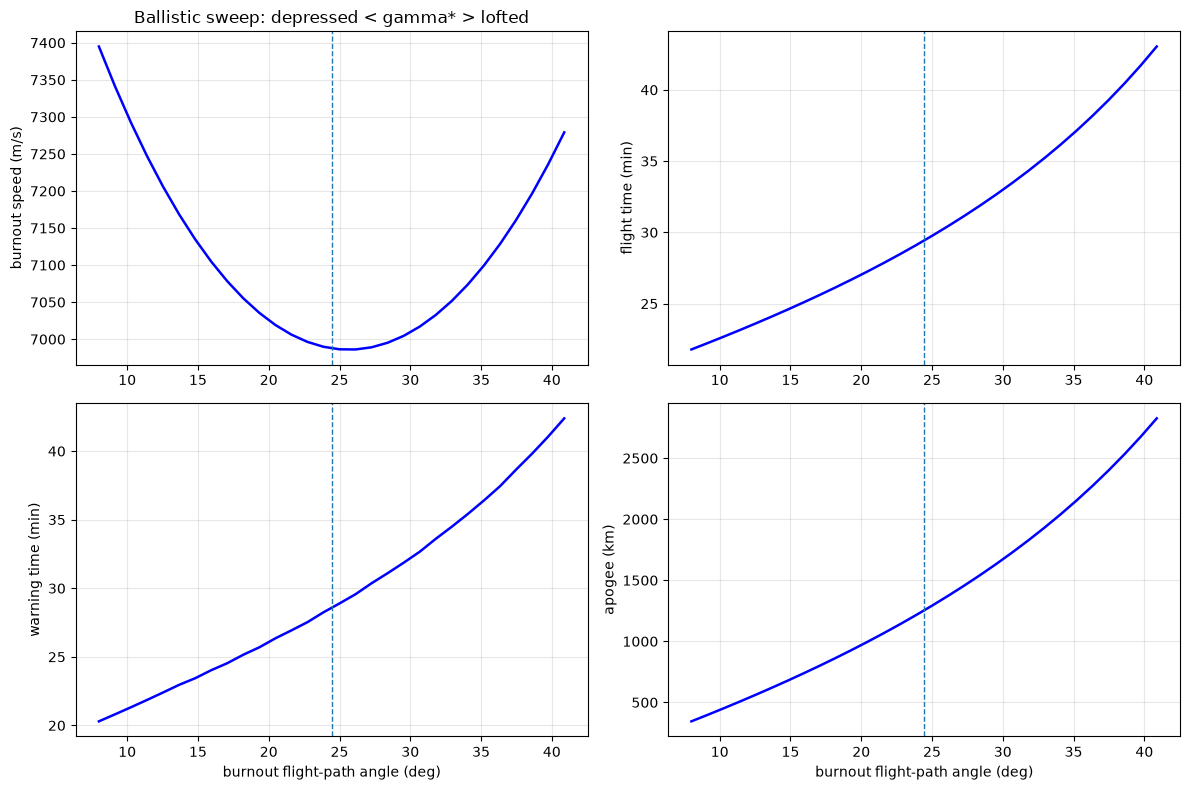

At minimum-energy gamma*: 24.44 deg
  burnout speed: 6,990 m/s
  flight time:   29.1 min
  warning time:  28.2 min
  apogee:        1215 km


In [ ]:
theta = float(separation / WGS84_MEAN_RADIUS)
gamma_star = optimum_burnout_angle(theta)
gammas = np.deg2rad(np.linspace(8.0, 2 * np.rad2deg(gamma_star) - 8.0, 30))

sweep_data = []
for gamma in gammas:
    c = warning_comparison(LAUNCH, TARGET, flight_path_angle=float(gamma),
                           parking_altitude=PARKING_ALTITUDE,
                           sites=tuple(EARLY_WARNING_SITES), samples=250,
                           earth_rotation=True)
    sweep_data.append((
        np.rad2deg(gamma),
        c.ballistic.burnout_speed,
        c.ballistic.flight_time / 60,
        c.ballistic_coverage.warning_time / 60 if c.ballistic_coverage.detected else np.nan,
        c.ballistic.apogee / 1e3,
    ))
sweep = np.array(sweep_data)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
labels = ['burnout speed (m/s)', 'flight time (min)', 'warning time (min)', 'apogee (km)']
for ax, col, label in zip(axes.ravel(), range(1, 5), labels):
    ax.plot(sweep[:, 0], sweep[:, col], 'b-', linewidth=1.8)
    ax.axvline(np.rad2deg(gamma_star), linestyle='--', linewidth=1)
    ax.set_ylabel(label); ax.grid(alpha=0.3)
for ax in axes[1]:
    ax.set_xlabel('burnout flight-path angle (deg)')
axes[0, 0].set_title('Ballistic sweep: depressed < gamma* > lofted')
plt.tight_layout()
plt.show()

idx_star = np.argmin(np.abs(sweep[:, 0] - np.rad2deg(gamma_star)))
print(f'At minimum-energy gamma*: {np.rad2deg(gamma_star):.2f} deg')
print(f'  burnout speed: {sweep[idx_star, 1]:,.0f} m/s')
print(f'  flight time:   {sweep[idx_star, 2]:.1f} min')
print(f'  warning time:  {sweep[idx_star, 3]:.1f} min')
print(f'  apogee:        {sweep[idx_star, 4]:.0f} km')

## Reading the worst case

The south-pole approach is the structural worst case:

1. **FOBS parking orbit** (orange) rides over the south pole where
   sensor coverage is thinnest
2. **Reversed bearing** — the vehicle emerges from the pole and crosses
   the target's longitude only minutes before entry, too late for
   northern-hemisphere sensors to react
3. **Detection sparse** — only one site detects the FOBS trajectory vs
   five for ballistic
4. **Warning removed** — 22+ minutes of warning conceded to the sensor
   network's geometry gap over the southern hemisphere